In [23]:
#|default_exp resnet

# ResNets

In [24]:
#|export
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *

In [25]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

import logging
logging.disable(logging.WARNING)

set_seed(42)

In [26]:
xl,yl = 'image','label'
name = "fashion_mnist"
bs = 1024
xmean,xstd = 0.28, 0.35

@inplace
def transformi(b): b[xl] = [(TF.to_tensor(o)-xmean)/xstd for o in b[xl]]

dsd = load_dataset(name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

In [27]:
#|export
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)

In [28]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]
iw = partial(init_weights, leaky=0.1)

## Going deeper

In [29]:
def get_model(act=nn.ReLU, nfs=(8,16,32,64,128), norm=nn.BatchNorm2d):
    # 构建一个纯卷积分类网络（Plain CNN），用于 Fashion MNIST（10分类）
    #
    # 参数说明:
    #   act  : 激活函数类，默认 ReLU；可替换为 GeneralRelu 等
    #   nfs  : 各层输出通道数的元组，默认 (8,16,32,64,128)，逐层加宽
    #   norm : 归一化层类，默认 BatchNorm2d；可设为 None 禁用
    #
    # conv(ni, nf, ...) 内部结构：Conv2d → Norm（如 BN）→ Act（如 ReLU）
    # 当 norm 存在时，bias 自动设为 False（BN 已包含偏置平移效果）

    # 第一层：1 → 8 通道，stride=1 保持空间尺寸不变（不下采样）
    # 输入: [B, 1, 28, 28]  →  输出: [B, 8, 28, 28]
    layers = [conv(1, 8, stride=1, act=act, norm=norm)]

    # 中间层：按 nfs 逐步加宽通道，stride=2（默认）每层将空间尺寸减半
    # 本例 nfs=(8,16,32,64,128) 生成 4 个卷积：
    #    8→16:  [B,  8, 28,28] → [B, 16, 14,14]
    #   16→32:  [B, 16, 14,14] → [B, 32,  7, 7]
    #   32→64:  [B, 32,  7, 7] → [B, 64,  4, 4]
    #   64→128: [B, 64,  4, 4] → [B,128,  2, 2]
    layers += [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]

    # 分类头：nfs[-1](128) → 10 类，stride=2 将 2×2 压成 1×1
    #   act=None  ：输出 logits，不加激活（CrossEntropyLoss 已含 softmax）
    #   bias=True ：显式加偏置（最终线性投影层不应依赖 BN 的平移）
    # [B,128,2,2] → Conv(stride=2) → [B,10,1,1] → Flatten → [B,10]
    return nn.Sequential(*layers, conv(nfs[-1], 10, act=None, norm=norm, bias=True), nn.Flatten()).to(def_device)

In [30]:
set_seed(42)
lr,epochs = 6e-2,5
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.806,0.700,0,train
0.849,0.466,0,eval
0.884,0.335,1,train
0.874,0.374,1,eval
0.908,0.258,2,train
0.900,0.281,2,eval
0.926,0.207,3,train
0.903,0.270,3,eval
0.941,0.167,4,train
0.922,0.225,4,eval


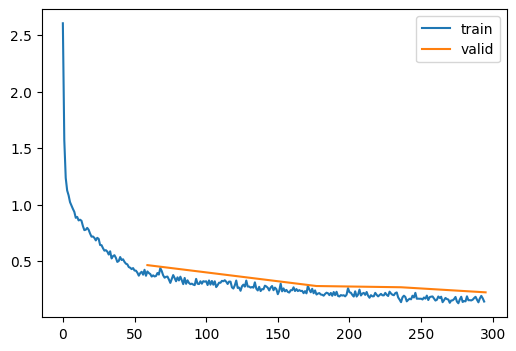

In [31]:
learn.fit(epochs)

## Skip Connections

The ResNet (*residual network*) was introduced in 2015 by Kaiming He et al in the article ["Deep Residual Learning for Image Recognition"](https://arxiv.org/abs/1512.03385). The key idea is using a *skip connection* to allow deeper networks to train successfully.

<img width="700" src="images/att_00042.png">

In [32]:
#|export

# ============================================================
# Skip Connection（跳跃连接）核心原理：
#
# 普通深层网络存在"退化问题"：层数越深，梯度越难传播，
# 导致训练误差反而升高（不是过拟合，而是优化困难）。
#
# ResNet 的解决思路：让每个残差块学习"残差 F(x)"而非直接映射。
#
#   普通块：  output = F(x)          （直接拟合目标函数）
#   残差块：  output = F(x) + x      （只需学习与恒等映射的"残差"）
#
# 若某层理论上应是恒等映射，残差块只需让 F(x)→0，更易优化。
# 跳跃连接还提供了梯度的"高速公路"：反向传播时梯度可以
# 直接通过加法跳过若干层，极大缓解梯度消失问题。
# ============================================================

def _conv_block(ni, nf, stride, act=act_gr, norm=None, ks=3):
    """
    构建残差块的主路径（Main Path），包含两个卷积层：
      conv1: ni→nf，stride=1（不改变空间尺寸），带激活函数
      conv2: nf→nf，stride=stride（控制是否下采样），无激活函数
             （激活放到残差加法之后，即 act(F(x)+x)，更利于梯度流动）

    注意 stride 只放在第二个卷积：
      - 先用 stride=1 的卷积做通道变换（ni→nf）
      - 再用 stride=stride 做空间下采样
      这比直接在第一层 stride 更稳定。
    """
    return nn.Sequential(conv(ni, nf, stride=1,      act=act,  norm=norm, ks=ks),  # 通道扩展，保持空间尺寸
                         conv(nf, nf, stride=stride, act=None, norm=norm, ks=ks))  # 空间下采样，无激活


class ResBlock(nn.Module):
    """
    残差块（Residual Block）= 主路径 F(x) + 跳跃连接（shortcut）x

    前向传播公式：output = act( F(x) + shortcut(x) )

    跳跃连接需满足：shortcut(x) 与 F(x) 的形状完全一致，
    才能做逐元素相加（element-wise addition）。
    形状不一致时有两种情况需要处理：
      1. 通道数不同（ni ≠ nf）：用 1×1 卷积做线性投影，调整通道数
      2. 空间尺寸不同（stride > 1）：用 AvgPool2d 做空间下采样
    """
    def __init__(self, ni, nf, stride=1, ks=3, act=act_gr, norm=None):
        super().__init__()

        # 主路径：两层卷积，学习残差 F(x)
        self.convs = _conv_block(ni, nf, stride, act=act, ks=ks, norm=norm)

        # 跳跃连接的通道对齐（Identity Connection / Projection Shortcut）：
        #   ni == nf → 通道相同，直接用恒等映射（noop）
        #   ni != nf → 通道不同，用 1×1 卷积（无激活）将 ni 通道投影到 nf 通道
        #              1×1 卷积本质是对每个像素点做线性变换，不改变空间尺寸
        self.idconv = fc.noop if ni==nf else conv(ni, nf, ks=1, stride=1, act=None)

        # 跳跃连接的空间对齐（处理 stride > 1 时空间尺寸不匹配）：
        #   stride == 1 → 主路径不下采样，跳跃连接也不需要池化
        #   stride >  1 → 主路径做了下采样，跳跃连接也需用 AvgPool 缩小空间尺寸
        #              选用 AvgPool（而非 MaxPool）更平滑，ceil_mode=True
        #              确保奇数尺寸（如 7×7）能正确对齐到 4×4
        self.pool = fc.noop if stride==1 else nn.AvgPool2d(2, ceil_mode=True)

        # 残差加法之后的激活函数（统一在合并后施加）
        self.act = act()

    def forward(self, x):
        # 数据流示意：
        #
        #   x ──→ [conv1 → act → conv2] ──────→ F(x)  (主路径，学习残差)
        #   │                                      │
        #   └──→ [pool（可选）→ idconv（可选）] ──→ shortcut(x)  (跳跃连接)
        #                                          │
        #                              F(x) + shortcut(x)
        #                                          │
        #                                        act()
        #                                          │
        #                                        output
        return self.act(self.convs(x) + self.idconv(self.pool(x)))

**Post-lesson update**: Piotr Czapla noticed that we forgot to include `norm=norm` in the call to `_conv_block` above, so the resnets in the lesson didn't have batchnorm in the resblocks! After fixing this, we discovered that initializing the `conv2` batchnorm weights to zero makes things worse in every model we tried, so we removed that. That init method was originally introduced to handle training extremely deep models (much deeper than we use here) -- it appears from this little test that it might be worse for less deep models.

In [33]:
def get_model(act=nn.ReLU, nfs=(8,16,32,64,128,256), norm=nn.BatchNorm2d):
    layers = [ResBlock(1, 8, stride=1, act=act, norm=norm)]
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) for i in range(len(nfs)-1)]
    layers += [nn.Flatten(), nn.Linear(nfs[-1], 10, bias=False), nn.BatchNorm1d(10)]
    return nn.Sequential(*layers).to(def_device)

In [34]:
def _print_shape(hook, mod, inp, outp): print(type(mod).__name__, inp[0].shape, outp.shape)
model = get_model()
learn = TrainLearner(model, dls, F.cross_entropy, cbs=[DeviceCB(), SingleBatchCB()])
with Hooks(model, _print_shape) as hooks: learn.fit(1, train=False)

ResBlock torch.Size([2048, 1, 28, 28]) torch.Size([2048, 8, 28, 28])
ResBlock torch.Size([2048, 8, 28, 28]) torch.Size([2048, 16, 14, 14])
ResBlock torch.Size([2048, 16, 14, 14]) torch.Size([2048, 32, 7, 7])
ResBlock torch.Size([2048, 32, 7, 7]) torch.Size([2048, 64, 4, 4])
ResBlock torch.Size([2048, 64, 4, 4]) torch.Size([2048, 128, 2, 2])
ResBlock torch.Size([2048, 128, 2, 2]) torch.Size([2048, 256, 1, 1])
Flatten torch.Size([2048, 256, 1, 1]) torch.Size([2048, 256])
Linear torch.Size([2048, 256]) torch.Size([2048, 10])
BatchNorm1d torch.Size([2048, 10]) torch.Size([2048, 10])


In [35]:
@fc.patch
def summary(self:Learner):
    res = '|Module|Input|Output|Num params|\n|--|--|--|--|\n'
    tot = 0
    def _f(hook, mod, inp, outp):
        nonlocal res,tot
        nparms = sum(o.numel() for o in mod.parameters())
        tot += nparms
        res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
    with Hooks(self.model, _f) as hooks: self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
    print("Tot params: ", tot)
    if fc.IN_NOTEBOOK:
        from IPython.display import Markdown
        return Markdown(res)
    else: print(res)

In [36]:
TrainLearner(get_model(), dls, F.cross_entropy, cbs=DeviceCB()).summary()

Tot params:  1228908


|Module|Input|Output|Num params|
|--|--|--|--|
|ResBlock|(2048, 1, 28, 28)|(2048, 8, 28, 28)|712|
|ResBlock|(2048, 8, 28, 28)|(2048, 16, 14, 14)|3696|
|ResBlock|(2048, 16, 14, 14)|(2048, 32, 7, 7)|14560|
|ResBlock|(2048, 32, 7, 7)|(2048, 64, 4, 4)|57792|
|ResBlock|(2048, 64, 4, 4)|(2048, 128, 2, 2)|230272|
|ResBlock|(2048, 128, 2, 2)|(2048, 256, 1, 1)|919296|
|Flatten|(2048, 256, 1, 1)|(2048, 256)|0|
|Linear|(2048, 256)|(2048, 10)|2560|
|BatchNorm1d|(2048, 10)|(2048, 10)|20|


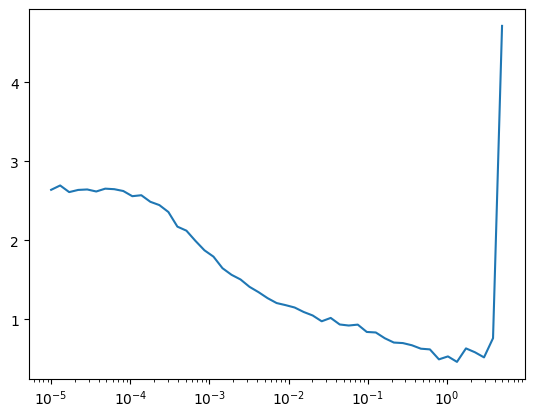

In [37]:
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
MomentumLearner(model, dls, F.cross_entropy, cbs=DeviceCB()).lr_find()

In [38]:
lr = 2e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.813,0.714,0,train
0.819,0.587,0,eval
0.893,0.349,1,train
0.880,0.360,1,eval
0.917,0.252,2,train
0.911,0.257,2,eval
0.937,0.192,3,train
0.924,0.225,3,eval
0.955,0.144,4,train
0.929,0.213,4,eval


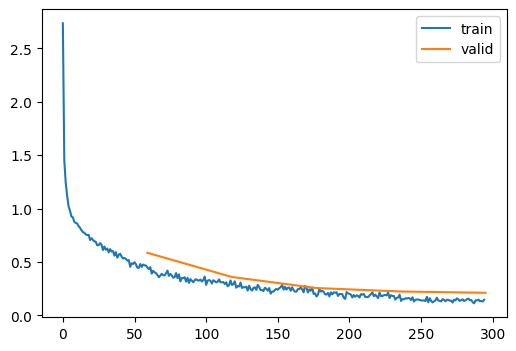

In [39]:
learn.fit(epochs)

In [40]:
import timm
from timm.models.resnet import BasicBlock, ResNet, Bottleneck

In [41]:
' '.join(timm.list_models('*resnet*'))

'cspresnet50 cspresnet50d cspresnet50w eca_resnet33ts ecaresnet26t ecaresnet50d ecaresnet50d_pruned ecaresnet50t ecaresnet101d ecaresnet101d_pruned ecaresnet200d ecaresnet269d ecaresnetlight gcresnet33ts gcresnet50t inception_resnet_v2 lambda_resnet26rpt_256 lambda_resnet26t lambda_resnet50ts legacy_seresnet18 legacy_seresnet34 legacy_seresnet50 legacy_seresnet101 legacy_seresnet152 nf_ecaresnet26 nf_ecaresnet50 nf_ecaresnet101 nf_resnet26 nf_resnet50 nf_resnet101 nf_seresnet26 nf_seresnet50 nf_seresnet101 resnet10t resnet14t resnet18 resnet18d resnet26 resnet26d resnet26t resnet32ts resnet33ts resnet34 resnet34d resnet50 resnet50_clip resnet50_clip_gap resnet50_gn resnet50_mlp resnet50c resnet50d resnet50s resnet50t resnet50x4_clip resnet50x4_clip_gap resnet50x16_clip resnet50x16_clip_gap resnet50x64_clip resnet50x64_clip_gap resnet51q resnet61q resnet101 resnet101_clip resnet101_clip_gap resnet101c resnet101d resnet101s resnet152 resnet152c resnet152d resnet152s resnet200 resnet200d 

```
resnet18:  block=BasicBlock, layers=[2, 2, 2, 2]
resnet18d: block=BasicBlock, layers=[2, 2, 2, 2], stem_width=32, stem_type='deep', avg_down=True
resnet10t: block=BasicBlock, layers=[1, 1, 1, 1], stem_width=32, stem_type='deep_tiered', avg_down=True
```

In [42]:
model = timm.create_model('resnet18d', in_chans=1, num_classes=10)
# model = ResNet(in_chans=1, block=BasicBlock, layers=[2,2,2,2], stem_width=32, avg_down=True)

In [43]:
lr = 2e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.779,0.634,0,train
0.645,1.647,0,eval
0.874,0.336,1,train
0.859,0.396,1,eval
0.906,0.249,2,train
0.895,0.291,2,eval
0.928,0.193,3,train
0.910,0.246,3,eval
0.946,0.148,4,train
0.919,0.227,4,eval


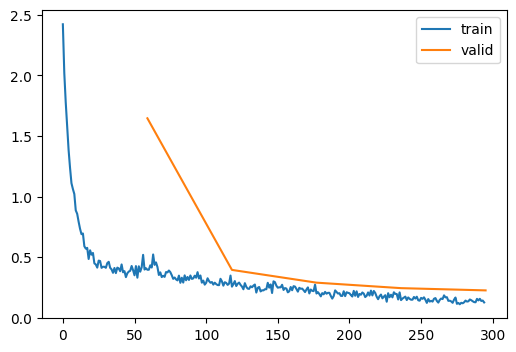

In [44]:
learn.fit(epochs)

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()